In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configurações padrão para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

DATA_PATH = '../data/final/dataset_gramado_completo.parquet'
IMAGE_DIR = '../data/images'

os.makedirs(IMAGE_DIR, exist_ok=True)

df = pd.read_parquet(DATA_PATH)

print(f"Dataset carregado com {df.shape[0]} filmes e {df.shape[1]} colunas.")
display(df.head(3))

Dataset carregado com 162 filmes e 15 colunas.


,festival_name,festival_year,release_year,award_category,title,directed by,duration,rating,vote_count,type,genre,id_movie,synopsis,tema_principal,analise_gemini
0,Festival de Gramado,2015,2014,"[filme, diretor, roteiro, música]",Ausência,Chico Teixeira,87,3.26,444,lm,[Drama],ausencia_2014,"Depois que seu pai abandona a família, Serginh...","Interior, Sertão e Natureza","{'analises': [{'aspecto': 'Roteiro', 'ponto_ch..."
1,Festival de Gramado,2015,2014,"[ator, júri da crítica]",O Último Cine Drive-in,Iberê Carvalho,100,3.34,891,lm,"[Comédia, Drama, Família]",o_ultimo_cine_drivein_2014,"Depois de muitos anos, Marlon volta à sua cida...","Interior, Sertão e Natureza","{'analises': [{'aspecto': 'Roteiro', 'ponto_ch..."
2,Festival de Gramado,2015,2015,"[ator, fotografia]",Um Homem Só,Cláudia Jouvin,88,3.26,579,lm,"[Drama, Ficção, Romance]",um_homem_so_2015,Arnaldo é um homem infeliz no casamento e no t...,Violência Urbana e Tráfico,"{'analises': [{'aspecto': 'Roteiro', 'ponto_ch..."


In [ ]:

registros_tags = []

# Função auxiliar para extrair a nota
def extrair_score(analise):
    if isinstance(analise, dict):
        metadados = analise.get('metadados_grafico')
        if isinstance(metadados, dict):
            return metadados.get('sentimento_geral_score')
    return None

df['gemini_score'] = df['analise_gemini'].apply(extrair_score)

# 2. ACHATAMENTO (FLATTENING) DAS TAGS
for index, row in df.iterrows():
    analise = row['analise_gemini']
    
    if isinstance(analise, dict):
        metadados = analise.get('metadados_grafico')
        if isinstance(metadados, dict):
            metricas = metadados.get('metricas', [])
            score = metadados.get('sentimento_geral_score')
            
            for metrica in metricas:
                registros_tags.append({
                    'id_movie': row['id_movie'],
                    'title': row.get('title'),
                    'genre': row.get('genre', []),
                    'tema_principal': row.get('tema_principal'), 
                    'rating_publico': row.get('rating'), 
                    'gemini_score': score,
                    'aspecto': metrica.get('aspecto'),
                    'nivel': metrica.get('nivel'),
                    'tag_tendencia': metrica.get('tag_tendencia')
                })

df_tags = pd.DataFrame(registros_tags)
print(f"Scores extraídos no df principal! E foram geradas {len(df_tags)} tags para o df_tags.")

Scores extraídos no df principal! E foram geradas 2380 tags para o df_tags.


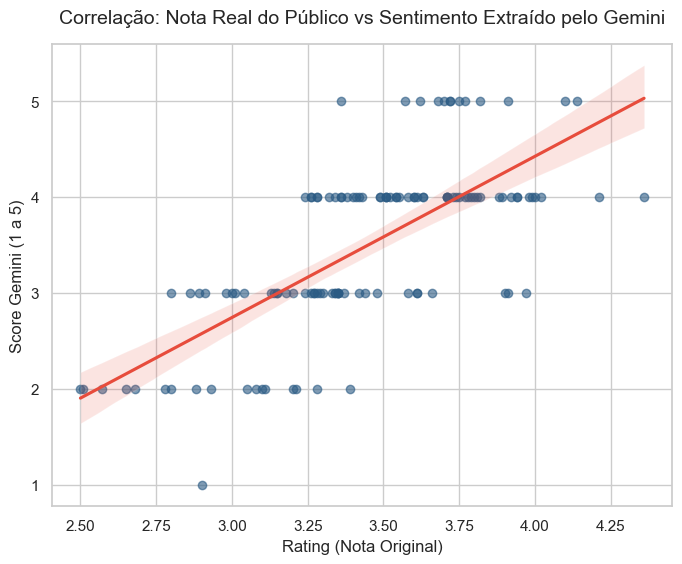

In [ ]:
# -----------------------------------------------------------------------
# INSIGHT 1: Correlação entre a Nota do Público e a Análise do Gemini
plt.figure(figsize=(8, 6))
sns.regplot(
    data=df, 
    x='rating', 
    y='gemini_score', 
    scatter_kws={'alpha':0.6, 'color': '#2b5b84'}, 
    line_kws={'color':'#e74c3c'}
)
plt.title('Correlação: Nota Real do Público vs Sentimento Extraído pelo Gemini', fontsize=14, pad=15)
plt.xlabel('Rating (Nota Original)')
plt.ylabel('Score Gemini (1 a 5)')

caminho_corr = os.path.join(IMAGE_DIR, 'correlacao_scores.png')
plt.savefig(caminho_corr, bbox_inches='tight', dpi=300)
plt.show()

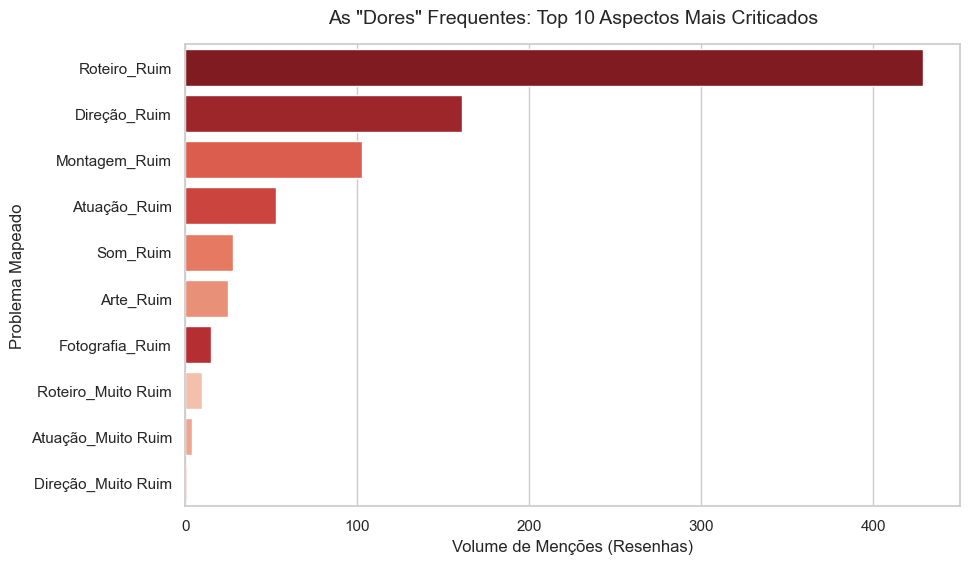

Salvo: ../data/images\top_dores_cinema.png


In [ ]:
# -----------------------------------------------------------------------
# INSIGHT 2: A "Dor" do Cinema Nacional (Principais Reclamações Técnicas)

negativas = df_tags[df_tags['nivel'].isin(['Ruim', 'Muito Ruim'])] # Filtra apenas tags negativas

plt.figure(figsize=(10, 6)) # Plota as 10 tags negativas mais frequentes

sns.countplot(
    data=negativas, 
    y='tag_tendencia',
    hue='tag_tendencia', 
    order=negativas['tag_tendencia'].value_counts().index[:10], 
    palette='Reds_r', # Gradiente vermelho para chamar atenção para o lado negativo
    legend=False
)
plt.title('As "Dores" Frequentes: Top 10 Aspectos Mais Criticados', fontsize=14, pad=15)
plt.xlabel('Volume de Menções (Resenhas)')
plt.ylabel('Problema Mapeado')

caminho_dores = os.path.join(IMAGE_DIR, 'top_dores_cinema.png')
plt.savefig(caminho_dores, bbox_inches='tight', dpi=300)
plt.show()
plt.close()
print(f"Salvo: {caminho_dores}")

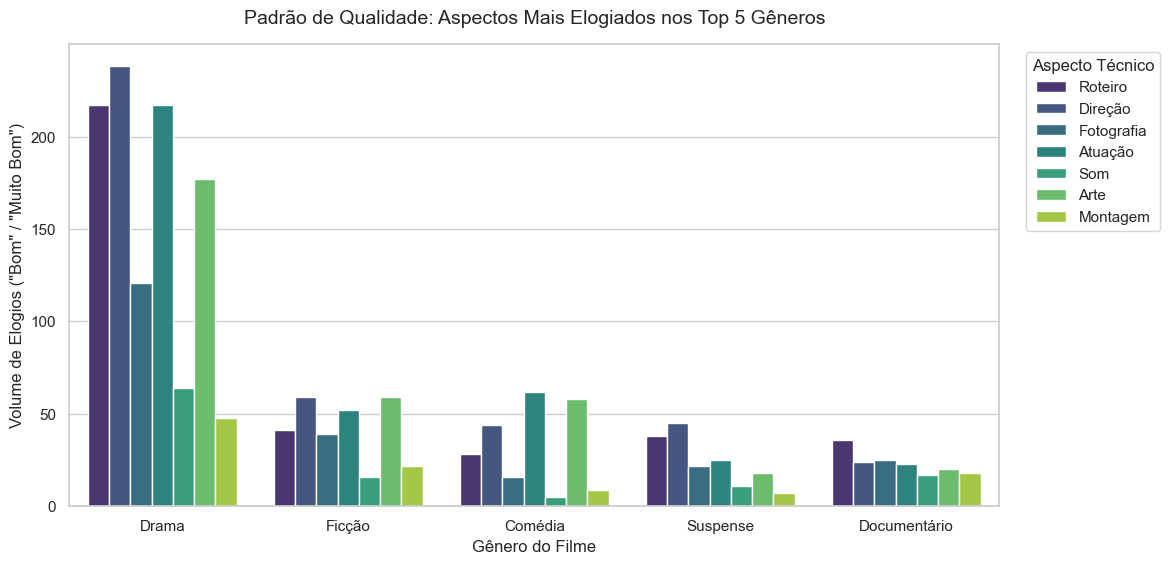

Salvo: ../data/images\forcas_por_genero.png


In [13]:
# -----------------------------------------------------------------------
# INSIGHT 3: Forças por Gênero (Onde cada gênero acerta?)
# Alguns filmes têm vários gêneros, precisando "explodir" a lista de gêneros

df_tags_exploded = df_tags.explode('genre')

top_5_generos = df_tags_exploded['genre'].value_counts().index[:5]
df_top_generos = df_tags_exploded[df_tags_exploded['genre'].isin(top_5_generos)]

# Filtramos apenas os elogios (Bom / Muito Bom)
positivas_genero = df_top_generos[df_top_generos['nivel'].isin(['Bom', 'Muito Bom'])]

plt.figure(figsize=(12, 6))
sns.countplot(
    data=positivas_genero, 
    x='genre', 
    hue='aspecto', 
    palette='viridis',
    order=top_5_generos
)
plt.title('Padrão de Qualidade: Aspectos Mais Elogiados nos Top 5 Gêneros', fontsize=14, pad=15)
plt.xlabel('Gênero do Filme')
plt.ylabel('Volume de Elogios ("Bom" / "Muito Bom")')
plt.legend(title='Aspecto Técnico', bbox_to_anchor=(1.02, 1), loc='upper left')

caminho_forcas = os.path.join(IMAGE_DIR, 'forcas_por_genero.png')
plt.savefig(caminho_forcas, bbox_inches='tight', dpi=300)
plt.show()
plt.close()
print(f"Salvo: {caminho_forcas}")

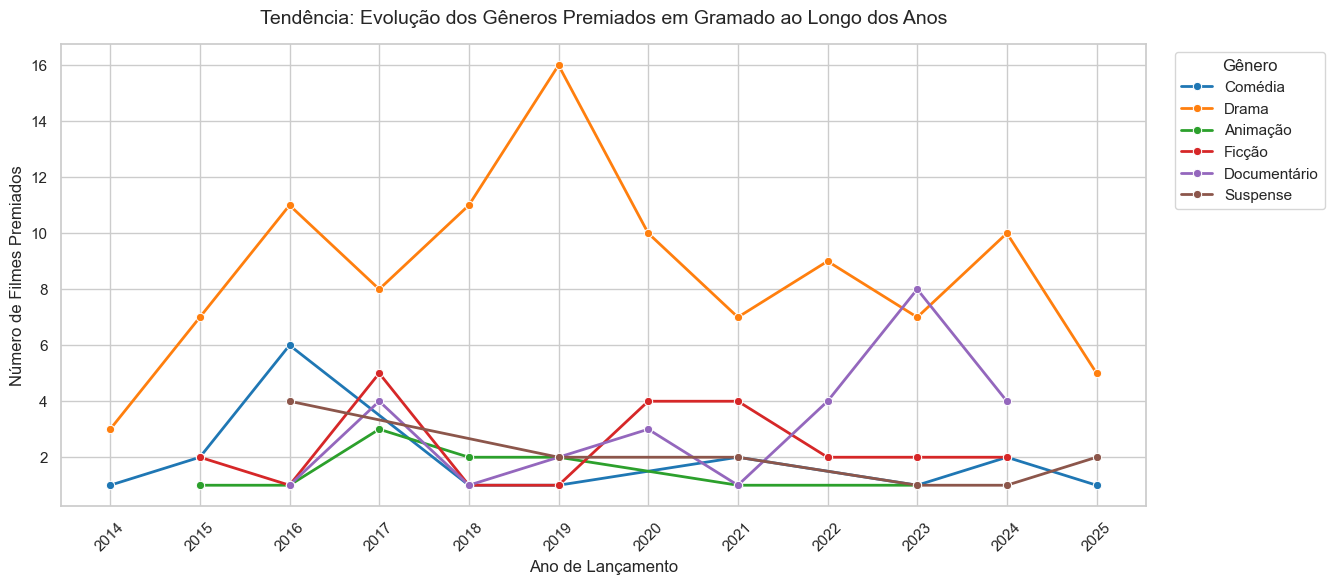

Salvo: ../data/images\tendencia_generos_anos.png


In [15]:
# -----------------------------------------------------------------------
# INSIGHT 4: Tendência de Gêneros Premiados ao Longo dos Anos
df_merged_exploded = df.explode('genre')

top_generos_historico = df_merged_exploded['genre'].value_counts().index[:6]
df_trend = df_merged_exploded[df_merged_exploded['genre'].isin(top_generos_historico)]

# Agrupando por Ano e Gênero e contando o número de filmes
tendencia_ano = df_trend.groupby(['release_year', 'genre']).size().reset_index(name='qtd_filmes')

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=tendencia_ano, 
    x='release_year', 
    y='qtd_filmes', 
    hue='genre', 
    marker='o', # Coloca uma bolinha em cada ano
    linewidth=2,
    palette='tab10'
)
plt.title('Tendência: Evolução dos Gêneros Premiados em Gramado ao Longo dos Anos', fontsize=14, pad=15)
plt.xlabel('Ano de Lançamento')
plt.ylabel('Número de Filmes Premiados')

plt.xticks(tendencia_ano['release_year'].unique(), rotation=45) 
plt.legend(title='Gênero', bbox_to_anchor=(1.02, 1), loc='upper left')

caminho_trend = os.path.join(IMAGE_DIR, 'tendencia_generos_anos.png')
plt.savefig(caminho_trend, bbox_inches='tight', dpi=300)
plt.show()
print(f"Salvo: {caminho_trend}")

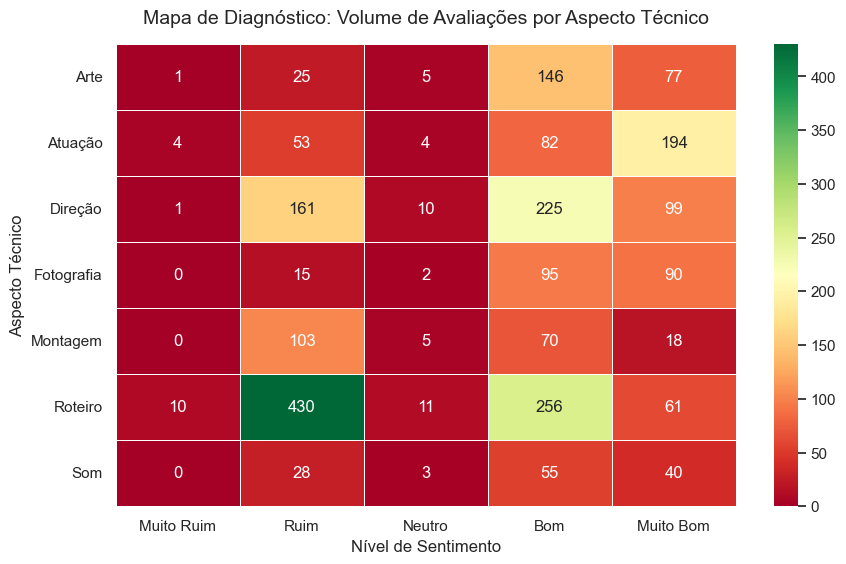

Salvo: ../data/images\heatmap_diagnostico.png


In [ ]:
# -----------------------------------------------------------------------
# INSIGHT 5: Mapa de Calor (Heatmap) Diagnóstico da Indústria
heatmap_data = pd.crosstab(df_tags['aspecto'], df_tags['nivel'])

# Forçar a ordem lógica das colunas (do pior para o melhor)
ordem_niveis = ['Muito Ruim', 'Ruim', 'Neutro', 'Bom', 'Muito Bom']

colunas_presentes = [col for col in ordem_niveis if col in heatmap_data.columns]
heatmap_data = heatmap_data[colunas_presentes]

plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_data, 
    annot=True,      # Mostra os números dentro dos quadrados
    fmt='d',         # Formato inteiro
    cmap='RdYlGn',   # Paleta Red-Yellow-Green (Vermelho é ruim, Verde é bom)
    linewidths=.5
)
plt.title('Mapa de Diagnóstico: Volume de Avaliações por Aspecto Técnico', fontsize=14, pad=15)
plt.xlabel('Nível de Sentimento')
plt.ylabel('Aspecto Técnico')

caminho_heatmap = os.path.join(IMAGE_DIR, 'heatmap_diagnostico.png')
plt.savefig(caminho_heatmap, bbox_inches='tight', dpi=300)
plt.show()
print(f"Salvo: {caminho_heatmap}")

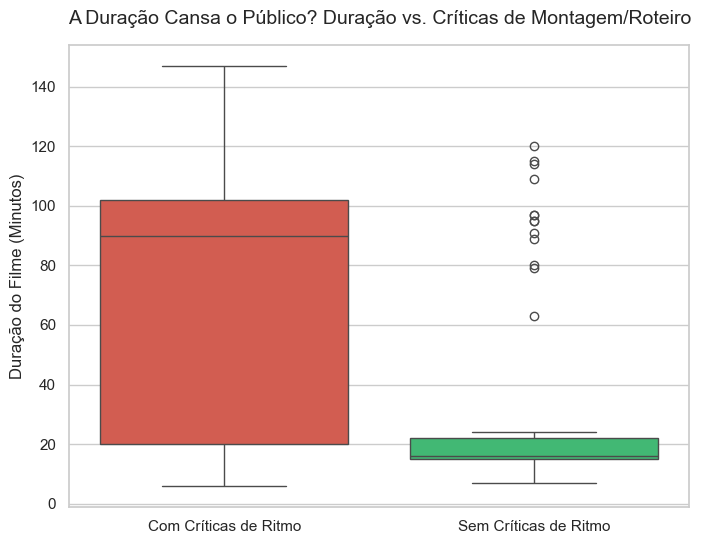

Salvo: ../data/images\boxplot_duracao_ritmo.png


In [ ]:
# -----------------------------------------------------------------------
# INSIGHT 6: Impacto da Duração nos Problemas de Ritmo (Boxplot)
# Considera problema se o filme tiver tags "Montagem_Ruim", "Montagem_Muito Ruim", etc.
tags_ritmo = ['Montagem_Ruim', 'Montagem_Muito Ruim', 'Roteiro_Ruim', 'Roteiro_Muito Ruim']


filmes_lentos = df_tags[df_tags['tag_tendencia'].isin(tags_ritmo)]['id_movie'].unique()


df['problema_ritmo'] = df['id_movie'].apply(
    lambda x: 'Com Críticas de Ritmo' if x in filmes_lentos else 'Sem Críticas de Ritmo'
)

plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df, 
    x='problema_ritmo', 
    y='duration', 
    hue='problema_ritmo',
    palette={'Com Críticas de Ritmo': '#e74c3c', 'Sem Críticas de Ritmo': '#2ecc71'},
    legend=False
)
plt.title('A Duração Cansa o Público? Duração vs. Críticas de Montagem/Roteiro', fontsize=14, pad=15)
plt.xlabel('')
plt.ylabel('Duração do Filme (Minutos)')

caminho_boxplot = os.path.join(IMAGE_DIR, 'boxplot_duracao_ritmo.png')
plt.savefig(caminho_boxplot, bbox_inches='tight', dpi=300)
plt.show()
print(f"Salvo: {caminho_boxplot}")

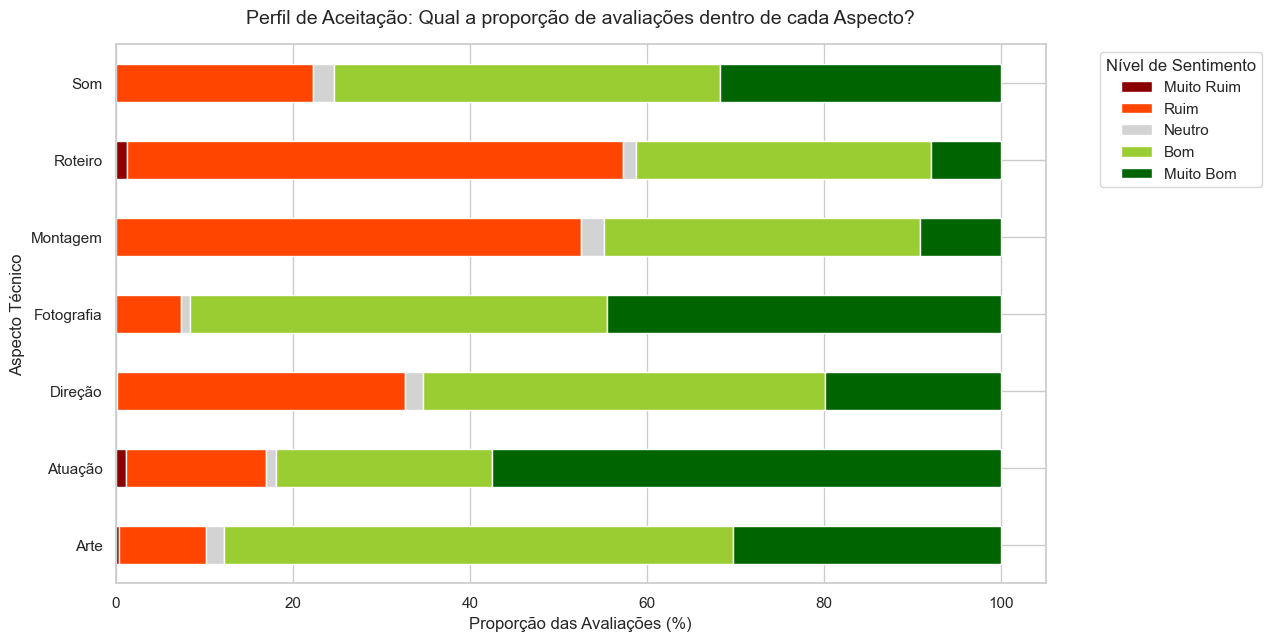

Salvo: ../data/images\barras_proporcao_sentimento.png
Gráficos gerados com sucesso!


In [ ]:
# -----------------------------------------------------------------------
# INSIGHT 7: Proporção de Sentimentos (Polarização)
# Transforma os dados absolutos do heatmap em porcentagens (soma da linha = 100%)
heatmap_perc = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

# Paleta de cores semântica
cores_niveis = {
    'Muito Ruim': '#8b0000', # Vermelho escuro
    'Ruim': '#ff4500',       # Laranja/Vermelho
    'Neutro': '#d3d3d3',     # Cinza
    'Bom': '#9acd32',        # Verde claro
    'Muito Bom': '#006400'   # Verde escuro
}


ax = heatmap_perc.plot(
    kind='barh', 
    stacked=True, 
    figsize=(12, 7),
    color=[cores_niveis.get(col, '#000000') for col in heatmap_perc.columns]
)

plt.title('Perfil de Aceitação: Qual a proporção de avaliações dentro de cada Aspecto?', fontsize=14, pad=15)
plt.xlabel('Proporção das Avaliações (%)')
plt.ylabel('Aspecto Técnico')

# Ajusta a legenda para fora do gráfico
plt.legend(title='Nível de Sentimento', bbox_to_anchor=(1.05, 1), loc='upper left')

caminho_proporcao = os.path.join(IMAGE_DIR, 'barras_proporcao_sentimento.png')
plt.savefig(caminho_proporcao, bbox_inches='tight', dpi=300)
plt.show()
print(f"Salvo: {caminho_proporcao}")

print("Gráficos gerados com sucesso!")